<a href="https://colab.research.google.com/github/JacksonGomesC/Sentinela-de-Pragas/blob/main/Sentinela_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a rel="license" href="https://faculdadesalvadorarena.org.br/"><img alt="FESA" style="border-width:0" src="https://faculdadesalvadorarena.org.br/wp-content/uploads/2022/07/logo_fesa.png" /></a><br />
**FESA - Inteligência Artificial (2026.1)** <br/>
**Projeto Sentinela - Arquitetura e Lógica de Controle** <br/>

Aluno(a): ANTÔNIO JACK S. MONTE -        RA: 062220002 <br/>
Aluno(a): GIOVANNA ALVES GONÇALVES -     RA: 062220006 <br/>
Aluno(a): JOSÉ DE JESUS AMARAL -         RA: 062220033 <br/>
Aluno(a): JACKSON GOMES CERQUEIRA -      RA: 062220030 <br/>

Data: 17/04/2026 <br/>

# 1. Setup e Instalação

In [1]:
# 1. Instalação das dependências com versões estáveis
!pip install -q scikit-fuzzy "numpy<2.0.0" google-generativeai pandas matplotlib

# 2. Imports
import pandas as pd
import numpy as np
import os
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import google.generativeai as genai
from google.colab import userdata
import matplotlib.pyplot as plt

# 3. Configuração do Gemini
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-flash-latest')
    print("✅ Setup concluído: Bibliotecas instaladas e Gemini configurado.")
except:
    print("⚠️ Aviso: Configure sua GOOGLE_API_KEY nos Secrets do Colab para o relatório funcionar.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Setup concluído: Bibliotecas instaladas e Gemini configurado.


#2. Gerador de Dados (ETL) com 500 pontos

In [2]:
# Configurações de reprodutibilidade
np.random.seed(42)
n_amostras = 500

data = {
    'id_ponto': range(1, n_amostras + 1),
    'latitude': np.random.uniform(-23.5500, -23.5600, n_amostras),
    'longitude': np.random.uniform(-46.6300, -46.6400, n_amostras),
    'ndvi': np.random.uniform(0.2, 0.9, n_amostras),
    'infestacao_pragas': np.random.uniform(0, 100, n_amostras),
    'temp_dossel': np.random.uniform(22, 38, n_amostras),
    'umidade_solo': np.random.uniform(10, 60, n_amostras)
}

df = pd.DataFrame(data)
os.makedirs('data', exist_ok=True)
df.to_csv('data/monitoramento_lavoura.csv', index=False)

print(f"✅ Dataset gerado: {len(df)} pontos salvos em /data/monitoramento_lavoura.csv")

✅ Dataset gerado: 500 pontos salvos em /data/monitoramento_lavoura.csv


#3.Motor de Decisão (Lógica Fuzzy)

In [3]:
# 1. Definição das variáveis
ndvi = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'ndvi')
infestacao = ctrl.Antecedent(np.arange(0, 101, 1), 'infestacao')
pulverizacao = ctrl.Consequent(np.arange(0, 101, 1), 'pulverizacao')

# 2. Fuzzificação
ndvi.automf(3, names=['pobre', 'medio', 'bom'])
infestacao.automf(3, names=['baixa', 'moderada', 'alta'])
pulverizacao.automf(3, names=['nula', 'economica', 'intensa'])

# 3. Regras
regra1 = ctrl.Rule(ndvi['pobre'] | infestacao['alta'], pulverizacao['intensa'])
regra2 = ctrl.Rule(ndvi['medio'] & infestacao['moderada'], pulverizacao['economica'])
regra3 = ctrl.Rule(ndvi['bom'] & infestacao['baixa'], pulverizacao['nula'])

# 4. Sistema
sistema_controle = ctrl.ControlSystem([regra1, regra2, regra3])
agente_decisor = ctrl.ControlSystemSimulation(sistema_controle)

print("✅ Motor de Decisão Fuzzy configurado com sucesso.")

✅ Motor de Decisão Fuzzy configurado com sucesso.


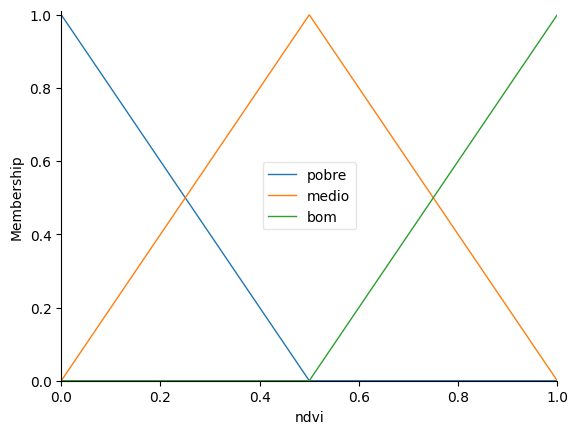

In [4]:
ndvi.view()

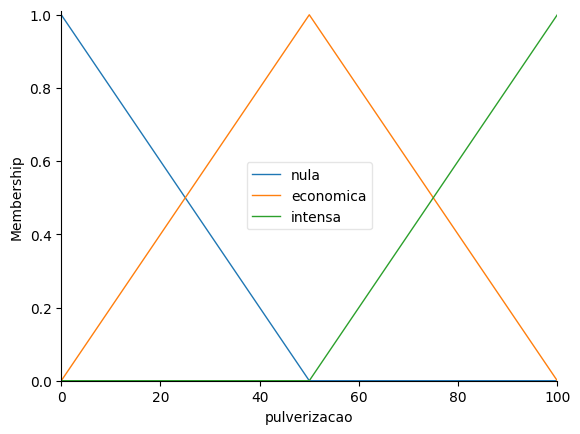

In [5]:
pulverizacao.view()

#4. Execução e IA Generativa (Relatório)

In [6]:
# Carregar dados
df = pd.read_csv('data/monitoramento_lavoura.csv')

# Processar os primeiros 3 pontos para demonstração
resultados = []
for index, row in df.head(3).iterrows():
    agente_decisor.input['ndvi'] = row['ndvi']
    agente_decisor.input['infestacao'] = row['infestacao_pragas']
    agente_decisor.compute()

    dosagem = agente_decisor.output['pulverizacao']

    # Chamar Gemini para análise interpretativa
    prompt = f"""
    Contexto: Sistema de Agrotécnica.
    Ponto: {row['id_ponto']} | NDVI: {row['ndvi']:.2f} | Infestação: {row['infestacao_pragas']:.2f}%
    Decisão Técnica Fuzzy: Pulverização em {dosagem:.2f}%

    Tarefa: Explique brevemente o porquê desta dosagem e dê um alerta estratégico.
    """

    response = model.generate_content(prompt)

    print(f"\n--- 🛰️ ANÁLISE DO PONTO {row['id_ponto']} ---")
    print(f"Decisão Técnica: {dosagem:.2f}% de pulverização")
    print(f"Relatório IA:\n{response.text}")


--- 🛰️ ANÁLISE DO PONTO 1.0 ---
Decisão Técnica: 52.73% de pulverização
Relatório IA:
Aqui está a explicação técnica e o alerta estratégico para o cenário apresentado:

### Explicação da Dosagem (52,73%)
A decisão do sistema Fuzzy baseia-se na correlação crítica entre os dois indicadores:
1.  **Infestação Elevada (51,91%):** O nível de infestação ultrapassou a metade da área, o que exige uma resposta imediata e robusta para evitar a perda total da produtividade.
2.  **NDVI Baixo (0,33):** Este valor indica que a cultura principal está com vigor vegetativo reduzido ou sofrendo estresse severo. 

**O Porquê:** A dosagem de **52,73%** é uma resposta de "intensidade moderada-alta". O sistema aplica uma dose ligeiramente superior à porcentagem de infestação para garantir a eliminação do agente agressor, mas não atinge a potência máxima (100%) para evitar a **fitotoxicidade**. Como o NDVI está baixo (0,33), a planta cultivada está frágil e uma dose excessiva de defensivo poderia prejudicar 